In [1]:
import sys
import os

os.chdir("../")
# Get the absolute path of the 'src' directory
src_path = os.path.abspath(os.path.join(os.getcwd(), ".."))  # Move one level up from 'experiments/'

# Add 'src' to Python's module search path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

In [2]:
from pseudoInverse.pigdm_ddim import DiffusionModel, PiGDM_DDIM
from pseudoInverse.pigdm_ddpm import PiGDM_DDPM
from pseudoInverse.operators import BlurOperator, InpaintingOperator, RotationOperator

from ddpm.model import DDPM
from ddpm.utils import save_pilimg, standardize_img, pilimg_to_tensor

from experiments.utils import evaluate_model, ImageDataset, plot_results, compute_psnr

from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt

import torch

## Gaussian Blurring 

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [4]:
dataset_path = "dataset/ffhq256-1k-validation"
dataset_size = len(os.listdir(dataset_path))

print(f"The Dataset FFHQ Contains : {dataset_size} Images\n")

# Image Dataset Intialization
dataset = ImageDataset(dataset_path)

The Dataset FFHQ Contains : 1000 Images



Text(0.5, 1.0, 'Image 1')

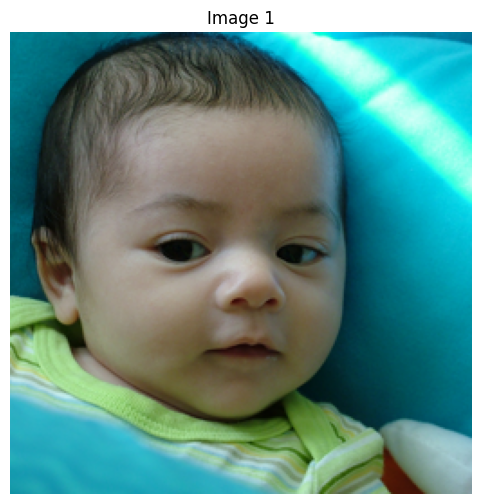

In [5]:
image_1 = standardize_img(dataset[0])

plt.figure(figsize=(6, 6))
plt.imshow(image_1)
plt.axis('off')
plt.title("Image 1")

In [6]:
# Loading Data For Test
subset_size = 10
indices = list(range(subset_size)) 

subset = Subset(dataset, indices)  
test_loader_all = DataLoader(subset, batch_size=1, shuffle=False)

### Sampling Using DDIM

In [7]:
# Create DataLoader
sigma = 100.0
kernel_size = 31 

measurement_operator = BlurOperator(kernel_size, sigma=sigma)

# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm) 

guidance_factor = 0.05

# Initialize sampler
pigdm_sampler = PiGDM_DDIM(model, measurement_operator, guidance_factor=guidance_factor)

  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Nizar\repos\ML\image_modelling\project\PiGDM\src\ddpm\model.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model_output = self.model(x, torch.tensor(t, device=device).unsqueeze(0))
100%|██████████| 100/100 [00:11<00:00,  8.58it/s]


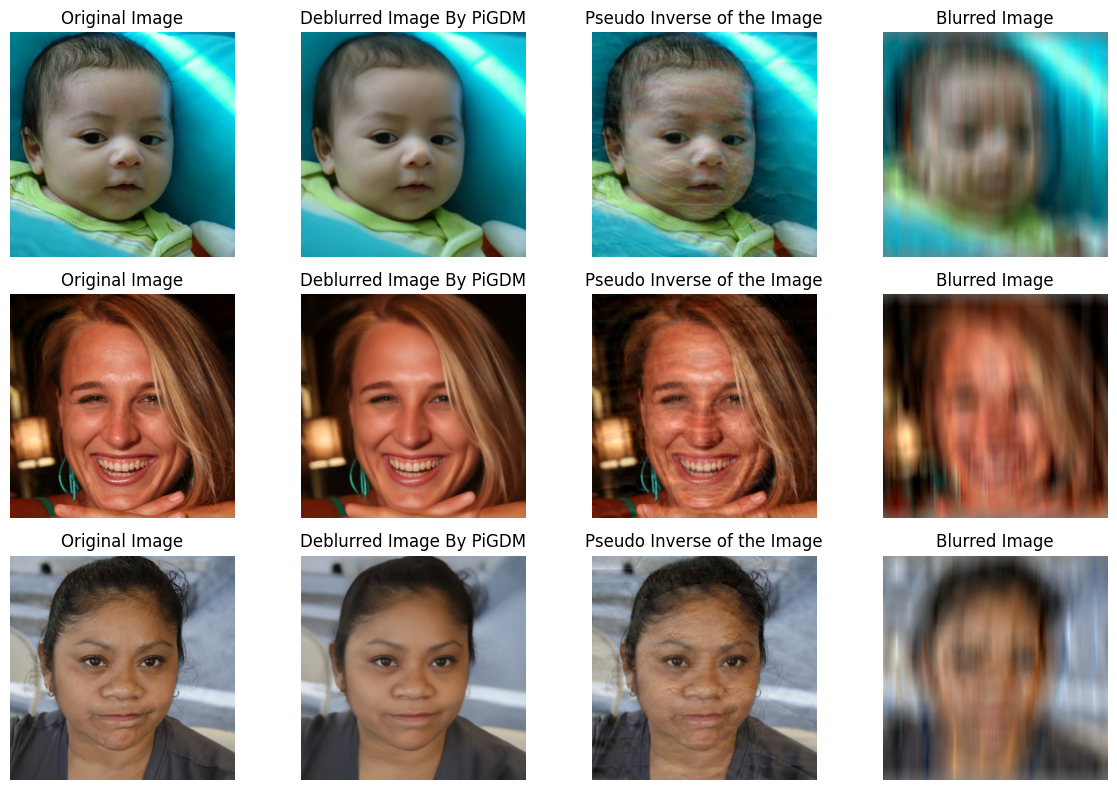

In [8]:
# Running Experiments on The 3 first images
# Noiseless Case

noiseless = True
num_steps = 100
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    deblurred_image = pigdm_sampler.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(deblurred_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Deblurred Image By PiGDM")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Blurred Image")



plt.tight_layout()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:11<00:00,  8.52it/s]


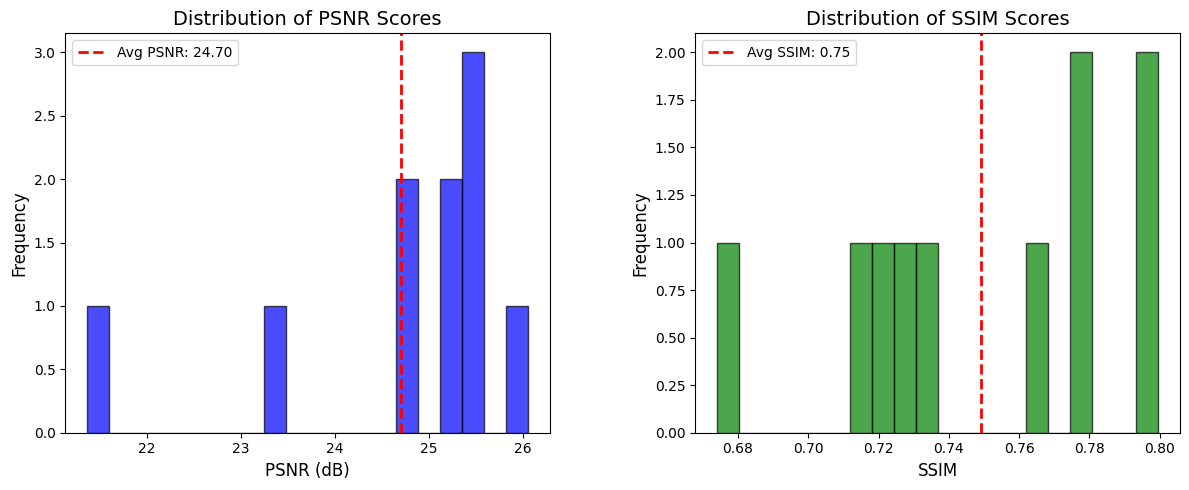

In [9]:
filename = "DDIM_noiseless.png"
folder_name = "experiments/results/blur/"

results_ddim_gaussian_deblur = evaluate_model(pigdm_sampler, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")
plot_results(results_ddim_gaussian_deblur, filename = filename, save_path = folder_name)

### Sampling with DDPM

In [10]:
# Create DataLoader
sigma = 100.0
kernel_size = 31 

measurement_operator = BlurOperator(kernel_size, sigma=sigma)

# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm) 

guidance_factor = 0.05

# Initialize sampler
pigdm_sampler = PiGDM_DDPM(model, measurement_operator, guidance_factor=guidance_factor)

noiseless = True
num_steps = 100
seed = 42

100%|██████████| 100/100 [00:11<00:00,  8.64it/s]


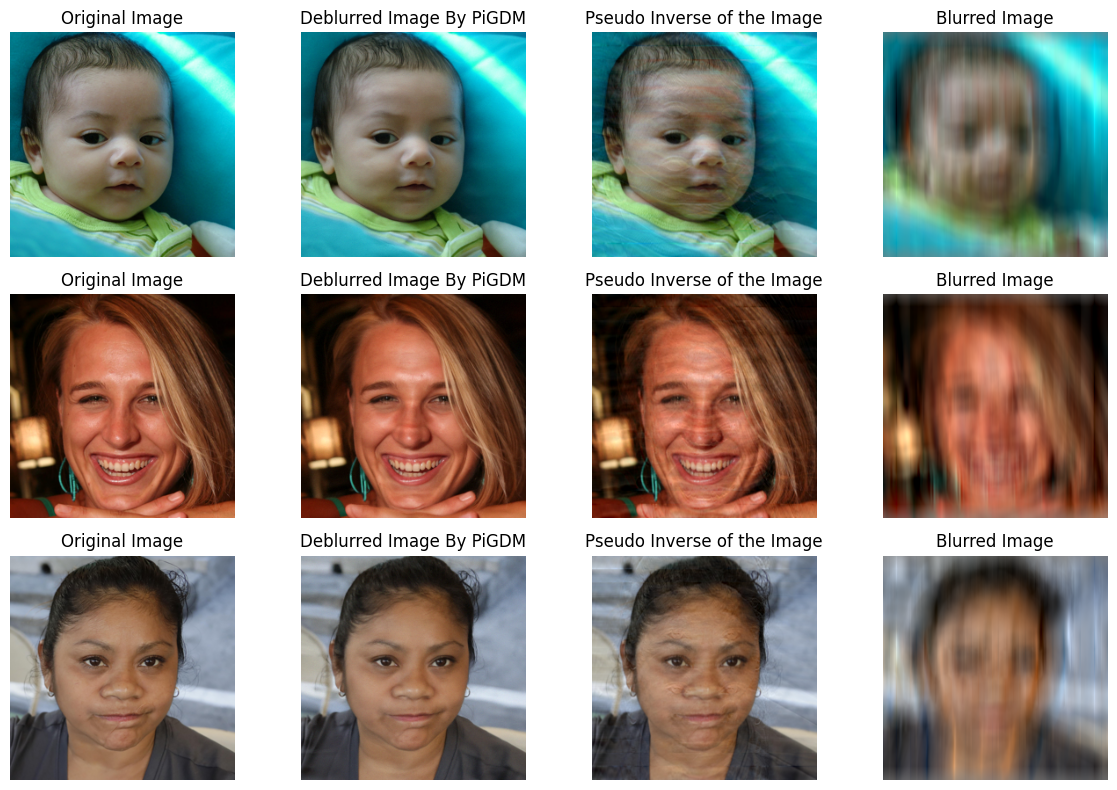

In [11]:
# Running Experiments on The 3 first images
# Noiseless Case

noiseless = True
num_steps = 100
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    deblurred_image = pigdm_sampler.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(deblurred_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Deblurred Image By PiGDM")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Blurred Image")



plt.tight_layout()
plt.show()

100%|██████████| 100/100 [00:43<00:00,  2.28it/s]


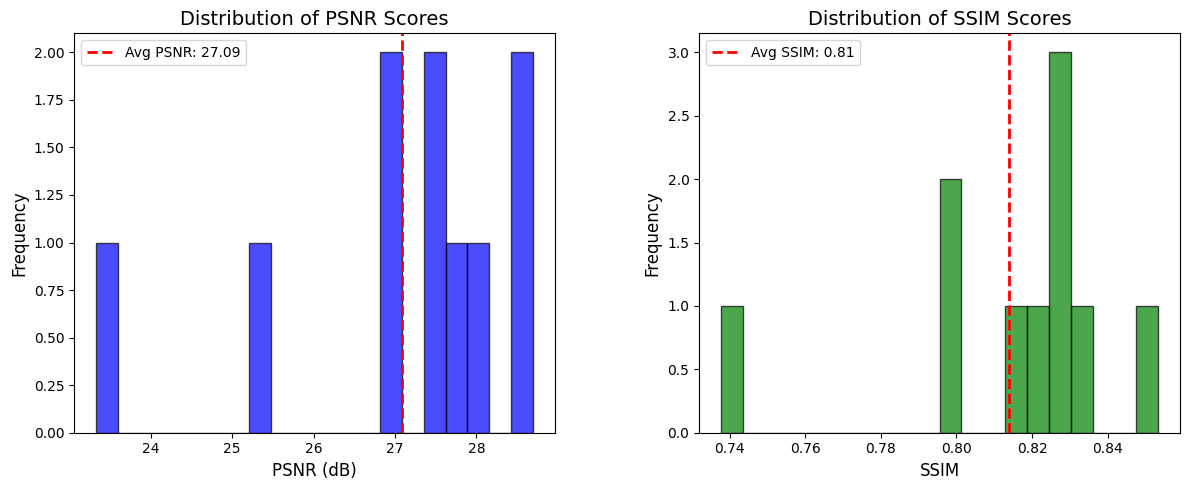

In [ ]:
filename = "DDPM_noiseless.png"
folder_name = "experiments/results/blur/"

results_ddpm_gaussian_deblur = evaluate_model(pigdm_sampler, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")
plot_results(results_ddpm_gaussian_deblur, filename=filename, save_path=folder_name)

### PSNR as a function of Sigma

In [ ]:
def psnr_vs_sigma(sigma_values, PIGDM, times=5):
    psnr_values = []
    n = len(dataset)
    for sigma in sigma_values:
        psnr_values_sigma = []
        for _ in range(times):
            # Select Randomly an Image
            idx = np.random.randint(0, n)

            image = dataset[idx].to(device)

            measurement_operator = BlurOperator(kernel_size, sigma=sigma)
            pigdm_sampler = PIGDM(model, measurement_operator, guidance_factor=guidance_factor)
            y = measurement_operator(image.unsqueeze(0))

            deblurred_image = pigdm_sampler.sample(
                y=y,
                num_steps=num_steps,
                noiseless=noiseless,
                seed=seed
            )
        
            psnr_values_sigma.append(compute_psnr(image.unsqueeze(0), deblurred_image))

        psnr_values.append(sum(psnr_values_sigma) / times)

    return psnr_values


import numpy as np

sigma_values = [1.0, 10.0, 20.0, 50.0, 100.0, 200.0, 1000.0, 5000.0]

# DDPM PSNR vs Sigma
ddpm_psnr_vs_sigma = psnr_vs_sigma(sigma_values, PiGDM_DDPM)
# DDIM PSNR vs Sigma
ddim_psnr_vs_sigma = psnr_vs_sigma(sigma_values, PiGDM_DDIM)

  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Mrabe\OneDrive\Bureau\cours MVA\Generative Models\project\PiGDM\src\ddpm\model.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model_output = self.model(x, torch.tensor(t, device=device).unsqueeze(0))
100%|██████████| 100/100 [03:12<00:00,  1.92s/it]


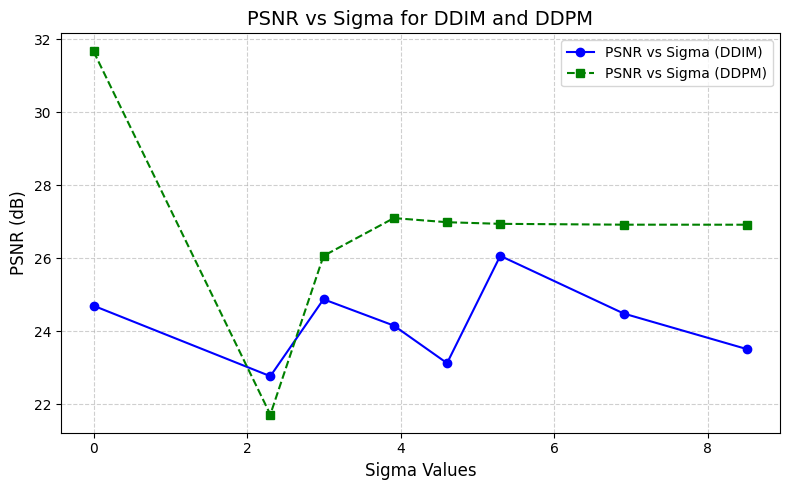

In [30]:
log_sigma_values = [np.log(sigma) for sigma in sigma_values]

plt.figure(figsize=(8, 5))  

# Plot first curve
plt.plot(log_sigma_values, ddim_psnr_vs_sigma, marker='o', linestyle='-', color='b', label="PSNR vs Sigma (DDIM)")

plt.plot(log_sigma_values, ddpm_psnr_vs_sigma, marker='s', linestyle='--', color='g', label="PSNR vs Sigma (DDPM)")

# Labels & Title
plt.xlabel("Sigma Values", fontsize=12)
plt.ylabel("PSNR (dB)", fontsize=12)
plt.title("PSNR vs Sigma for DDIM and DDPM", fontsize=14)

# Grid & Legend
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

## Inpainting

### DDIM Sampling

In [13]:
img_shape = 256, 256
ratio_mask = 0.3
measurement_operator = InpaintingOperator(img_shape, ratio_mask, block_size=None, random=True)

# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm) 

guidance_factor = 0.05

# Initialize sampler
pigdm_sampler = PiGDM_DDIM(model, measurement_operator, guidance_factor=guidance_factor)

noiseless = True
num_steps = 100
seed = 42

100%|██████████| 100/100 [00:11<00:00,  8.58it/s]


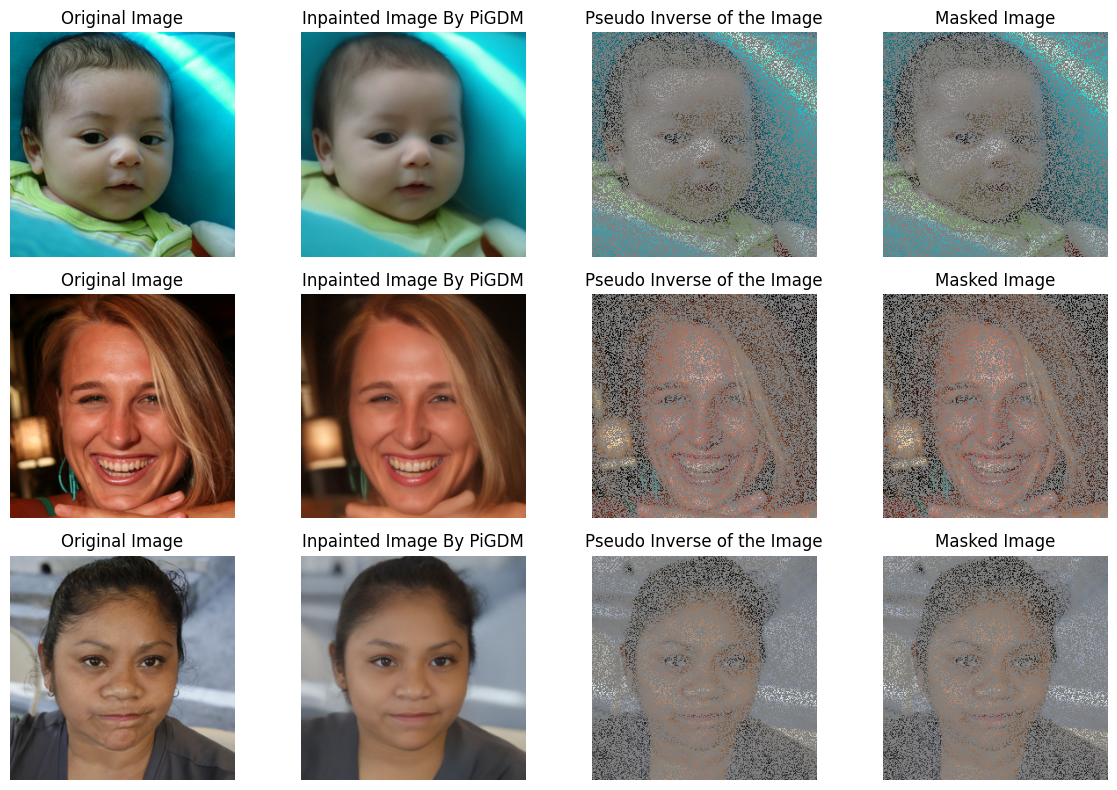

In [14]:
# Running Experiments on The 3 first images

noiseless = True
num_steps = 100
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    inpainted_image = pigdm_sampler.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(inpainted_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Inpainted Image By PiGDM")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Masked Image")



plt.tight_layout()
plt.show()

100%|██████████| 100/100 [00:11<00:00,  8.34it/s]


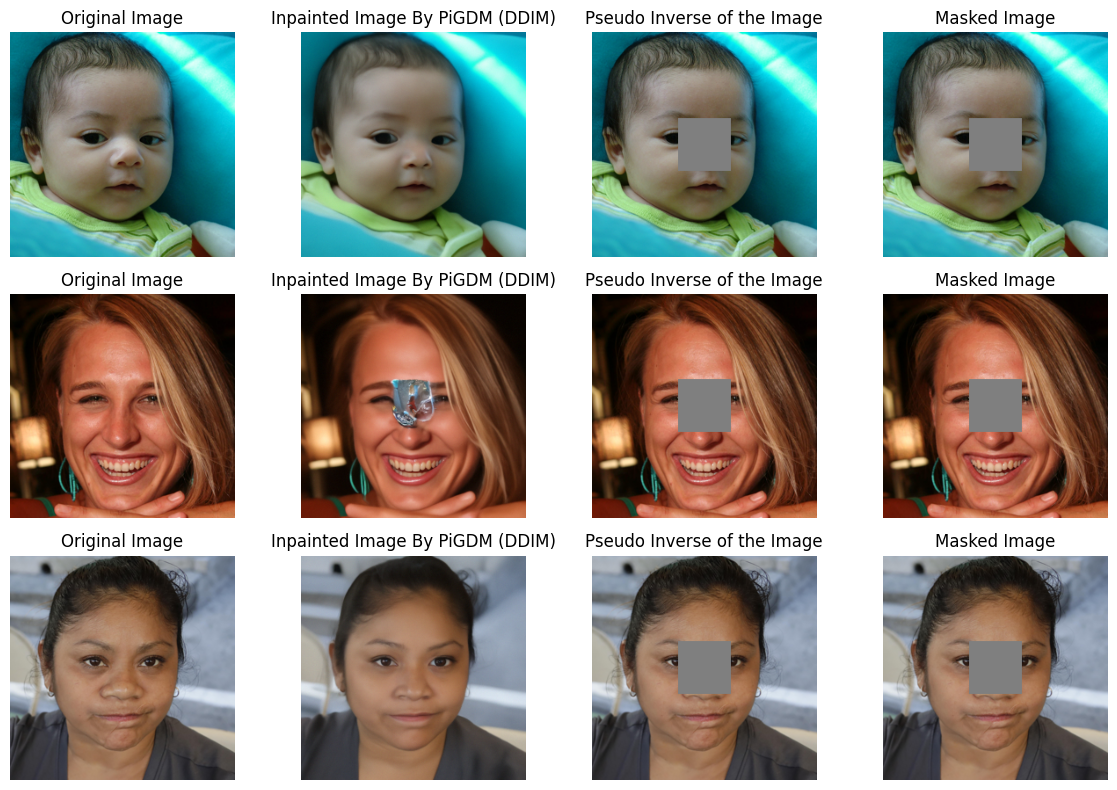

In [15]:
# Running Experiments on The 3 first images
# Here I will use a square mask

noiseless = True
num_steps = 100
seed = 42
random = False
block_size = 60

measurement_operator = InpaintingOperator(img_shape, ratio_mask=None, block_size=block_size, random=random)

# Initialize sampler
pigdm_sampler_inpainting_block = PiGDM_DDIM(model, measurement_operator, guidance_factor=guidance_factor)

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    inpainted_image = pigdm_sampler_inpainting_block.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(inpainted_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Inpainted Image By PiGDM (DDIM)")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Masked Image")



plt.tight_layout()
plt.show()

100%|██████████| 100/100 [00:11<00:00,  8.75it/s]


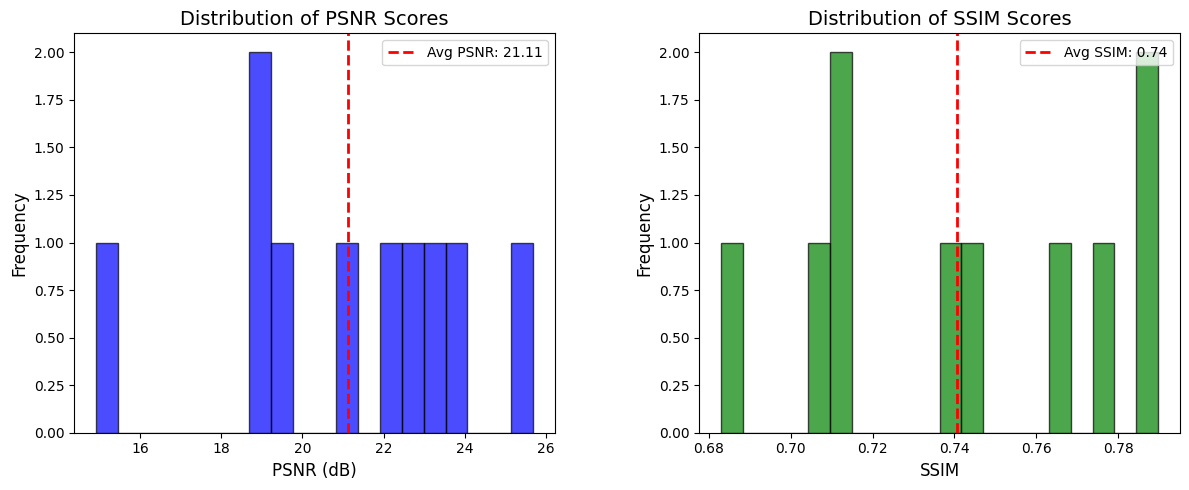

In [16]:
filename = "DDIM_noiseless.png"
folder_name = "experiments/results/inpainting/"

results_ddim_inpainting = evaluate_model(pigdm_sampler_inpainting_block, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")
plot_results(results_ddim_inpainting, filename=filename, save_path=folder_name)

### DDPM Sampling

In [17]:
# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm) 

guidance_factor = 0.05

# Initialize sampler
pigdm_sampler_ddpm = PiGDM_DDPM(model, measurement_operator, guidance_factor=guidance_factor)

noiseless = True
num_steps = 1000
seed = 42

100%|██████████| 1000/1000 [01:59<00:00,  8.38it/s]


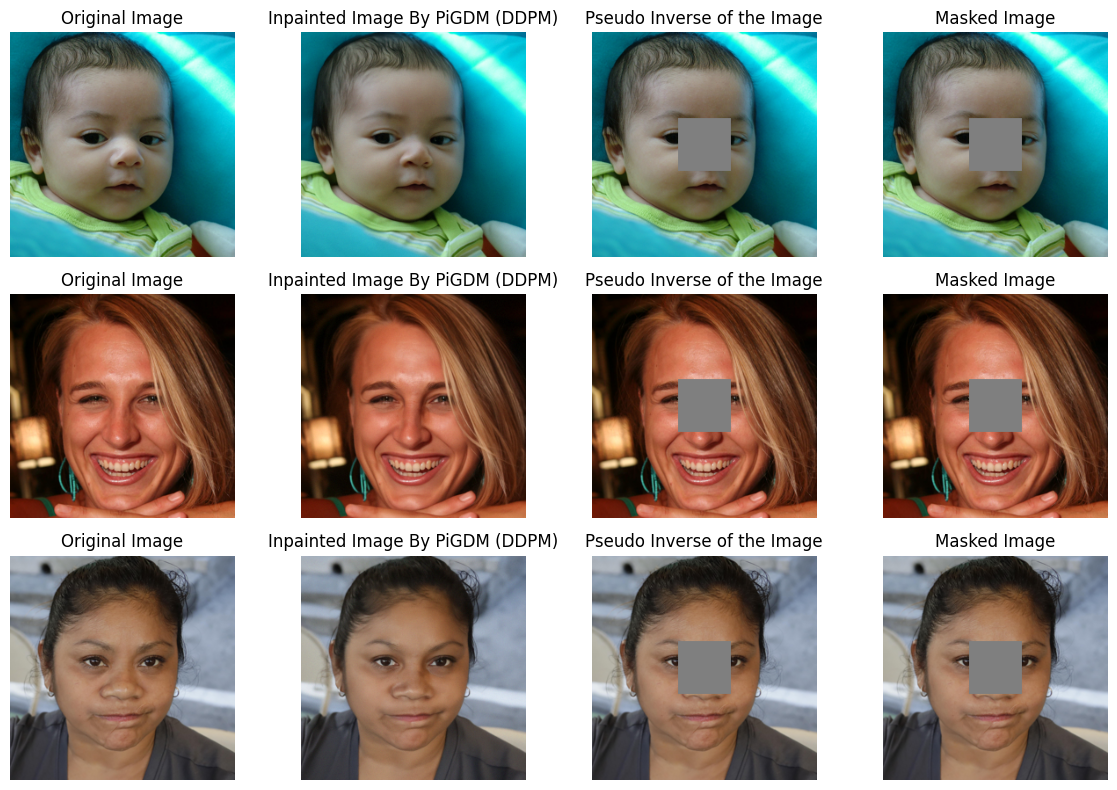

In [18]:
# Running Experiments on The 3 first images

noiseless = True
num_steps = 1000
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    inpainted_image = pigdm_sampler_ddpm.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(inpainted_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Inpainted Image By PiGDM (DDPM)")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Masked Image")



plt.tight_layout()
plt.show()

100%|██████████| 1000/1000 [02:01<00:00,  8.26it/s]


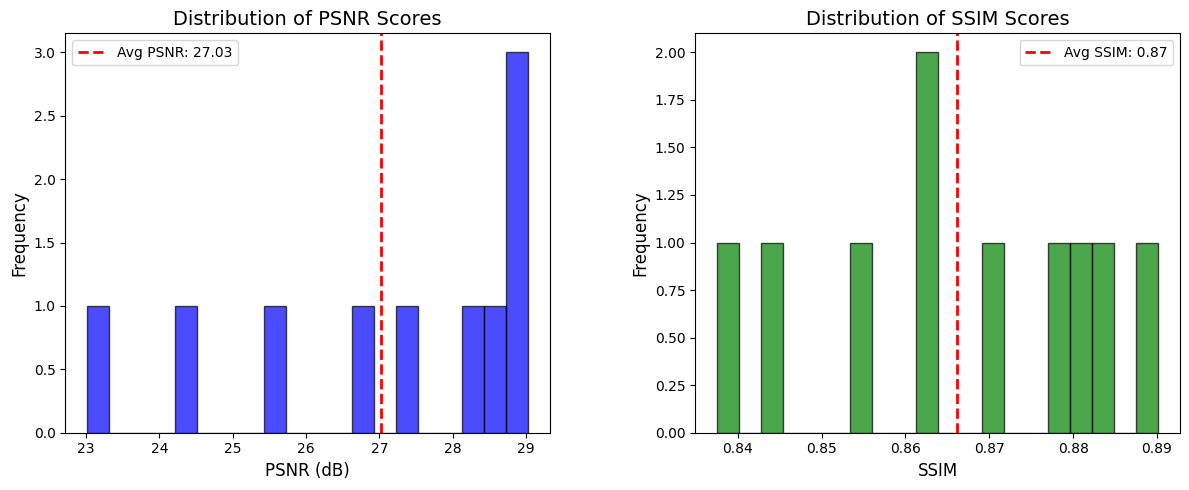

In [19]:
filename = "DDPM_noiseless.png"
folder_name = "experiments/results/inpainting/"

results_ddpm_inpainting = evaluate_model(pigdm_sampler_ddpm, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")
plot_results(results_ddpm_inpainting, filename=filename, save_path=folder_name)

## Rotation Operator

### DDIM Sampling

In [20]:
theta = 45 ## In degrees
measurement_operator = RotationOperator(theta)

# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm)

guidance_factor = 0.05

# Initialize sampler
pigdm_sampler_rotation_ddim = PiGDM_DDIM(model, measurement_operator, guidance_factor=guidance_factor)

noiseless = True
num_steps = 100
seed = 42

  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Nizar\repos\ML\image_modelling\project\PiGDM\src\ddpm\model.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model_output = self.model(x, torch.tensor(t, device=device).unsqueeze(0))
100%|██████████| 100/100 [00:12<00:00,  8.18it/s]


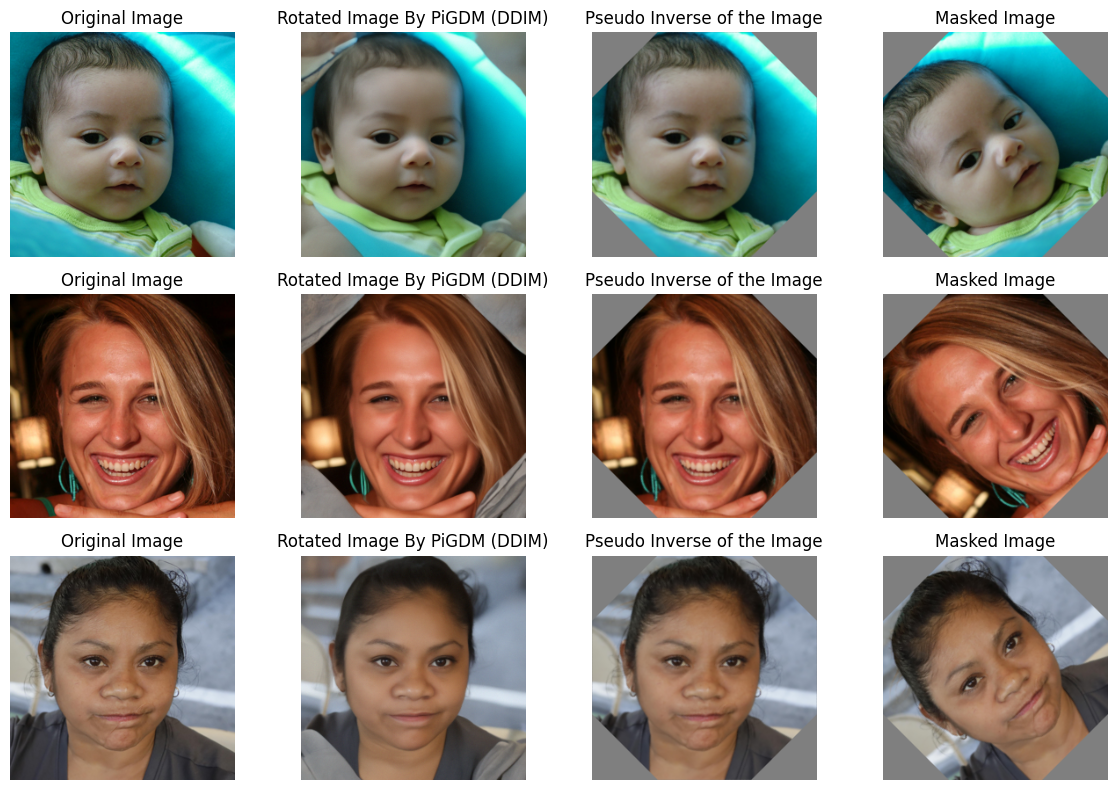

In [21]:
# Running Experiments on The 3 first images
noiseless = True
num_steps = 100
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    inpainted_image = pigdm_sampler_rotation_ddim.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(inpainted_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Rotated Image By PiGDM (DDIM)")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Masked Image")



plt.tight_layout()
plt.show()

100%|██████████| 100/100 [00:12<00:00,  8.31it/s]


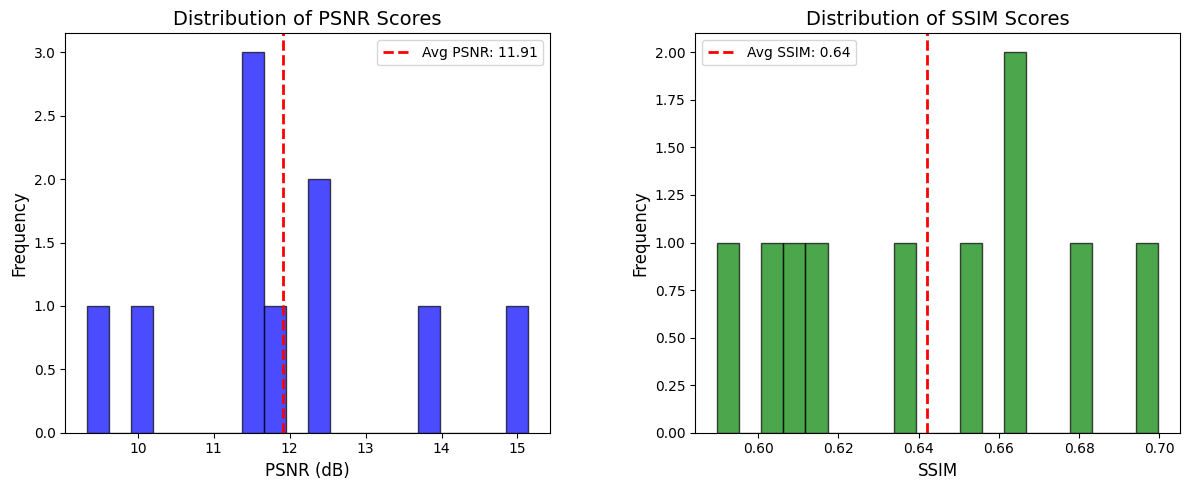

In [23]:
filename = "DDIM_noiseless.png"
folder_name = "experiments/results/rotation/"

results_ddim_rotation = evaluate_model(pigdm_sampler_rotation_ddim, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")
plot_results(results_ddim_rotation, filename=filename, save_path=folder_name)

# DDPM Sampling

In [24]:
# Initialize sampler
pigdm_sampler_rotation_ddpm = PiGDM_DDPM(model, measurement_operator, guidance_factor=guidance_factor)

100%|██████████| 100/100 [00:12<00:00,  8.08it/s]


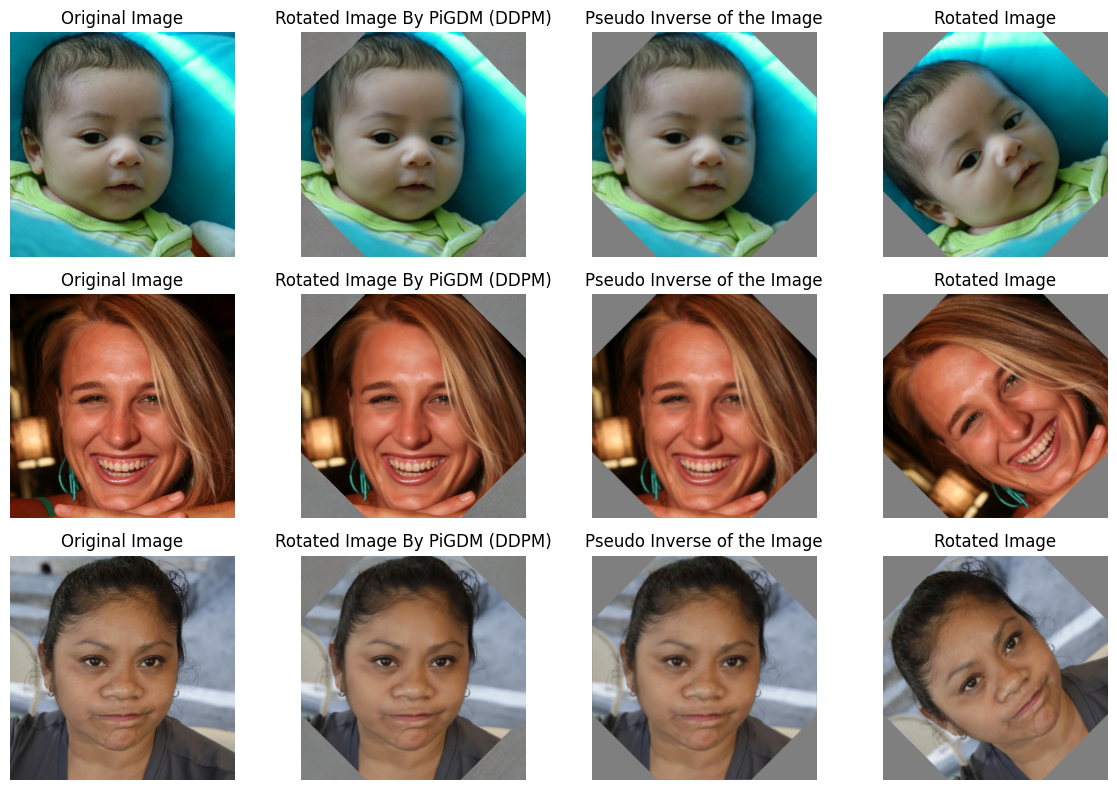

In [25]:
# Running Experiments on The 3 first images
noiseless = True
num_steps = 100
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    reconstructed_image = pigdm_sampler_rotation_ddpm.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(reconstructed_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Rotated Image By PiGDM (DDPM)")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Rotated Image")



plt.tight_layout()
plt.show()

100%|██████████| 100/100 [00:12<00:00,  8.11it/s]


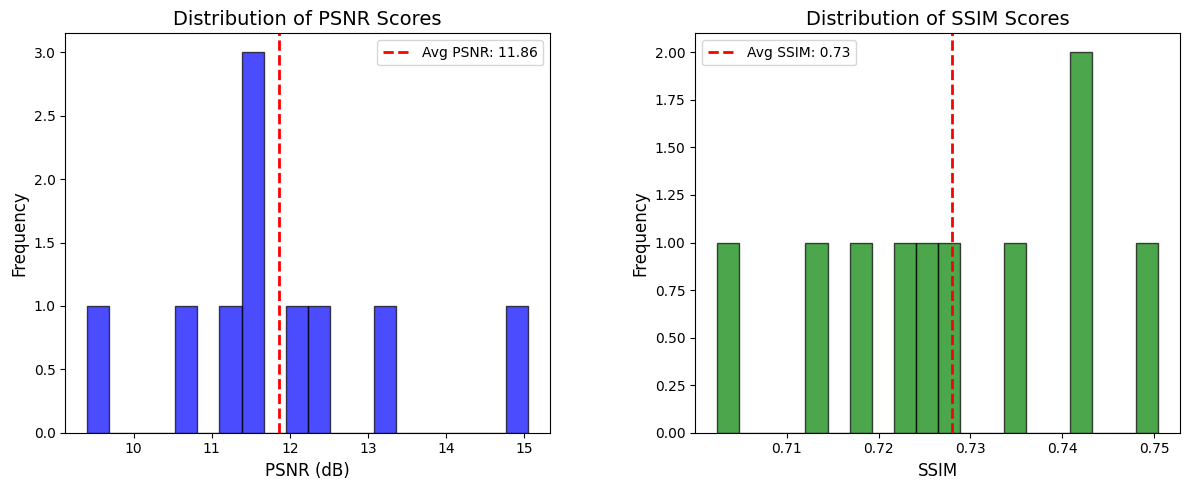

In [26]:
filename = "DDPM_noiseless.png"
folder_name = "experiments/results/rotation/"

results_ddpm_rotation = evaluate_model(pigdm_sampler_rotation_ddpm, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")
plot_results(results_ddpm_rotation, filename=filename, save_path=folder_name)